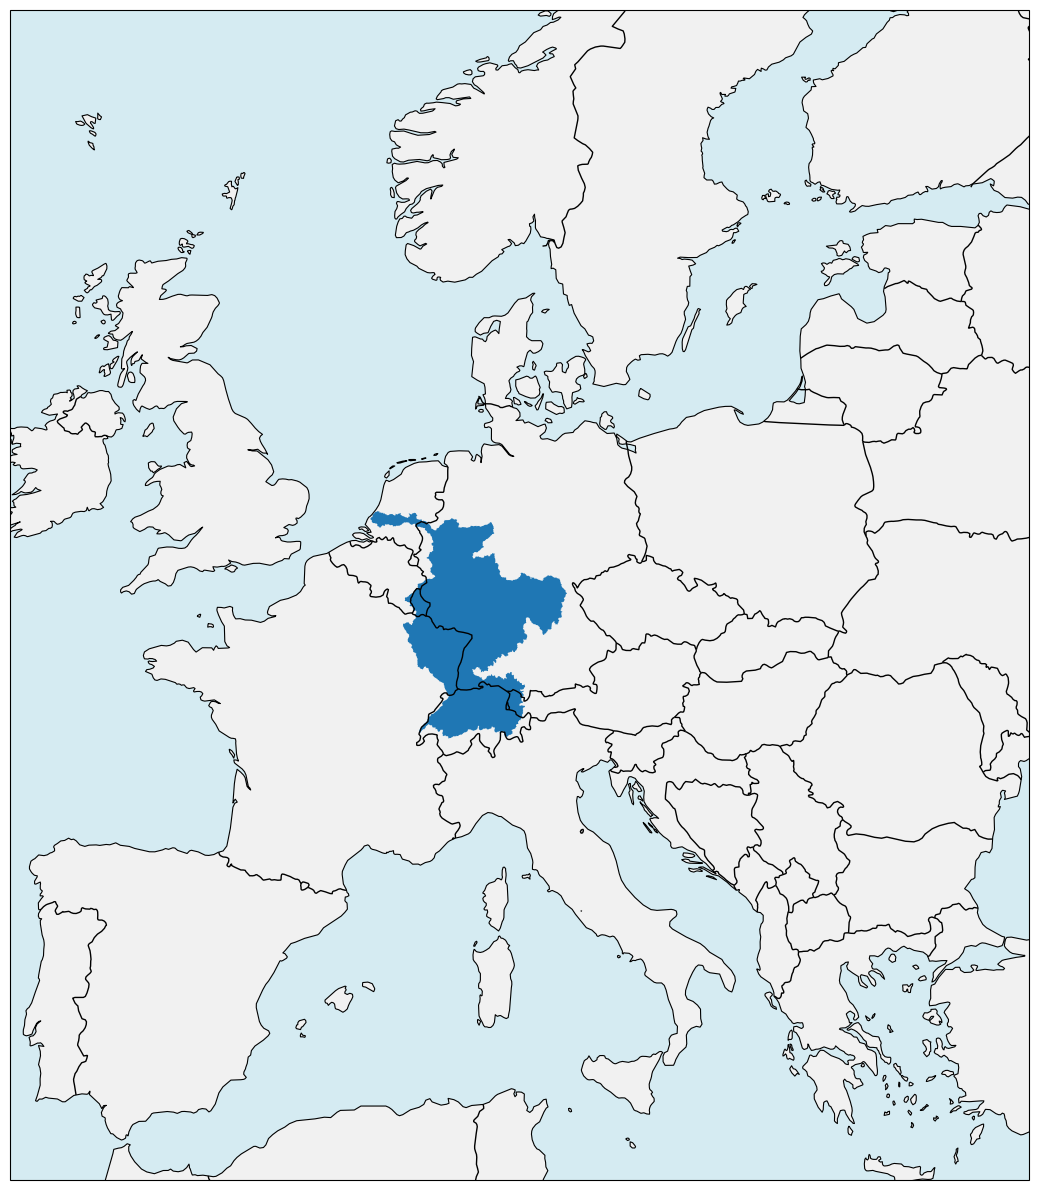


✓ Karte gespeichert!

Suche den Rhein auf der Karte:
  - Fläche: ~185.000 km²
  - Lage: Schweiz/Deutschland/Niederlande
  - Notiere die MAIN_BAS Nummer


In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Level 3 laden - hier sind die großen Flüsse
basins_lev3 = gpd.read_file('./data/HydroBasins/download/mrb_basins.shp')

# Karte mit Ländergrenzen
fig, ax = plt.subplots(
    figsize=(16, 12),
    subplot_kw={'projection': ccrs.PlateCarree()}
)

# Europa-Ausdehnung
ax.set_extent([-10, 30, 35, 65], crs=ccrs.PlateCarree())

# Hintergrund: Länder
ax.add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.3)
ax.add_feature(cfeature.OCEAN, facecolor='lightblue', alpha=0.5)
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linestyle='-', linewidth=1, edgecolor='black')  # Ländergrenzen

# Flusseinzugsgebiete Level 3 drüber
basins_lev3.plot(
    ax=ax)


plt.tight_layout()
#plt.savefig('europe_level3_mit_laendern.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Karte gespeichert!")
print("\nSuche den Rhein auf der Karte:")
print("  - Fläche: ~185.000 km²")
print("  - Lage: Schweiz/Deutschland/Niederlande")
print("  - Notiere die MAIN_BAS Nummer")

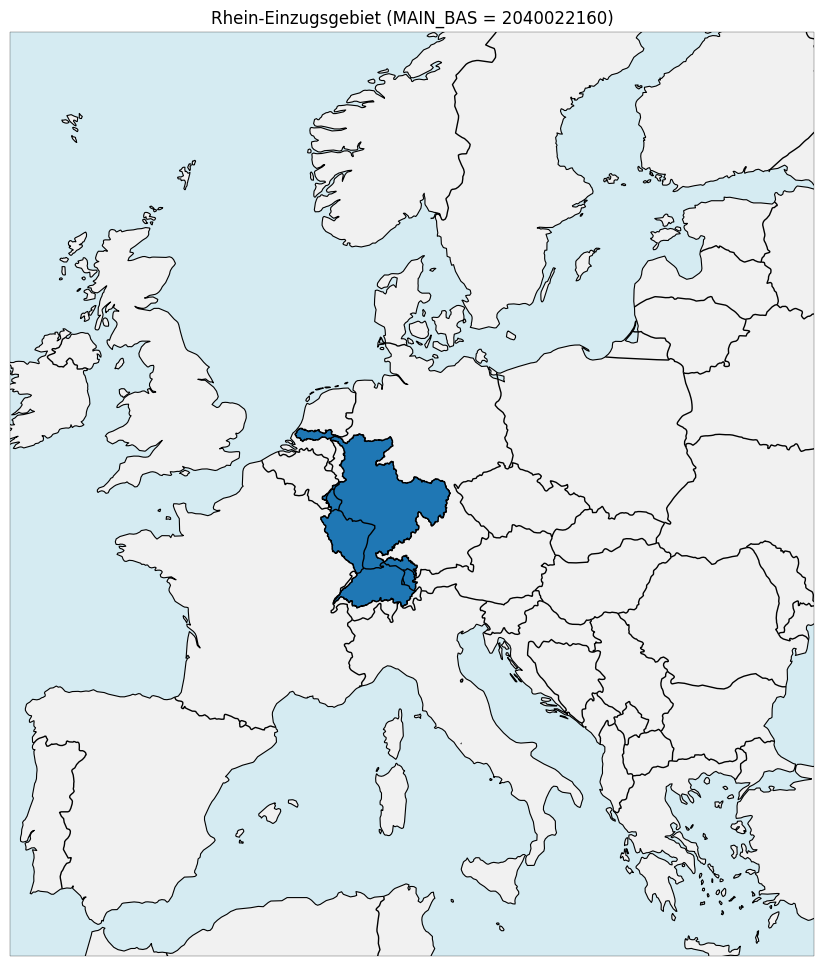

In [68]:
import matplotlib.pyplot as plt

import geopandas as gpd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

basins_lev4 = gpd.read_file('./data/HydroBasins/hybas_eu_lev01-12_v1c/hybas_eu_lev04_v1c.shp')

# Rhein-Polygone auswählen
rhine = basins_lev4[basins_lev4["MAIN_BAS"] == 2040023010]#2040022160
#2040023010
# Falls mehrere Teilpolygone existieren → zu einem Polygon verschmelzen
rhine_diss = rhine.dissolve()
fig, ax = plt.subplots(
    figsize=(16, 12),
    subplot_kw={'projection': ccrs.PlateCarree()}
)

# Europa-Ausdehnung
ax.set_extent([-10, 30, 35, 65], crs=ccrs.PlateCarree())

# Ganz Europa in hellgrau zum Vergleich
basins_lev3.plot(ax=ax, color="lightgrey", edgecolor="none")

# Rhein hervorheben
rhine_diss.plot(ax=ax, edgecolor="black")

ax.add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.3)
ax.add_feature(cfeature.OCEAN, facecolor='lightblue', alpha=0.5)
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linestyle='-', linewidth=1, edgecolor='black')  # Ländergrenzen

ax.set_title("Rhein-Einzugsgebiet (MAIN_BAS = 2040022160)")
plt.show()


/Users/ericwostenberg/Documents/GitHub/snow_storage_and_snowmelt_in_nuclear_winter/.venv/lib/python3.11/site-packages/geopandas/geodataframe.py:1891: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  result = super().__getitem__(key)


ValueError: aspect must be finite and positive 

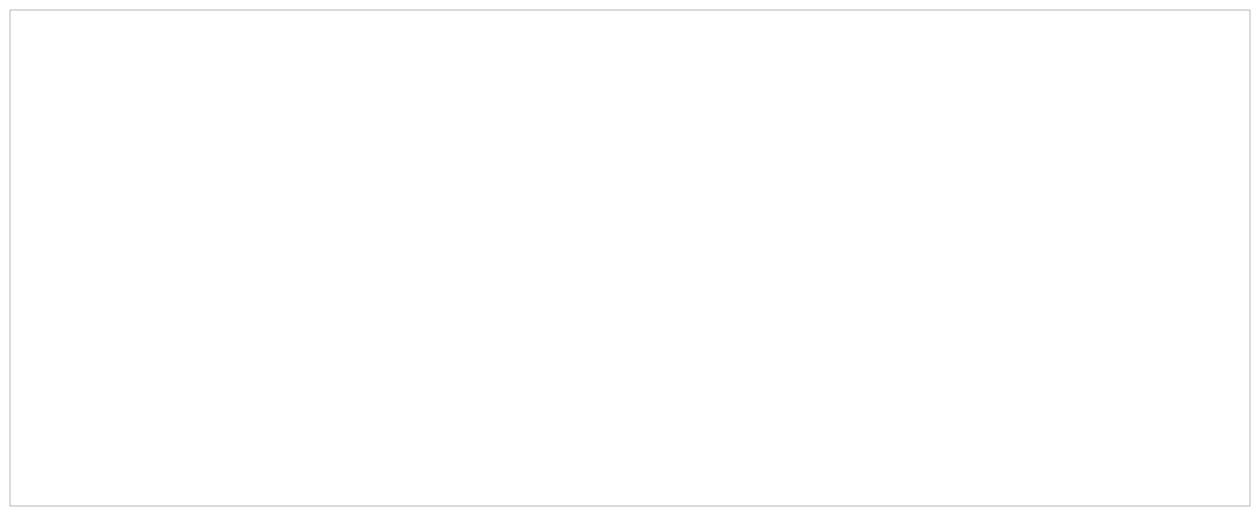

In [70]:
import matplotlib.pyplot as plt
import geopandas as gpd
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

# Daten laden
basins_lev4_asia = gpd.read_file('./data/HydroBasins/hybas_as_lev01-12_v1c/hybas_as_lev04_v1c.shp')
basins_dissolved = basins_lev4_asia.dissolve(by="MAIN_BAS", as_index=False)  
#rhine = basins_lev4[basins_lev4["MAIN_BAS"] == 2040023010]#2040022160
yellow_river = basins_lev4_asia[basins_lev4["MAIN_BAS"]==4040007850]
# Nach MAIN_BAS gruppieren und auflösen
yellow_river_dissolved = yellow_river.dissolve()

# Figur erstellen
fig, ax = plt.subplots(
    figsize=(16, 12),
    subplot_kw={'projection': ccrs.PlateCarree()}
)

# Zoom auf Yellow River Region (Nord-/Zentralchina)
ax.set_extent([95, 120, 32, 42], crs=ccrs.PlateCarree())

# Farbpalette für die verschiedenen Einzugsgebiete
n_basins = len(basins_dissolved)
colors = plt.cm.tab20(np.linspace(0, 1, n_basins))

# Einzugsgebiete plotten mit verschiedenen Farben
yellow_river_dissolved.plot(
    ax=ax, 
    color=colors, 
    edgecolor="black", 
    linewidth=1.5,
    alpha=0.7
)

# Beschriftungen hinzufügen (größere Schrift beim Zoom)
for idx, row in basins_dissolved.iterrows():
    centroid = row.geometry.centroid
    # Nur Beschriftungen im sichtbaren Bereich
    if 95 <= centroid.x <= 120 and 32 <= centroid.y <= 42:
        ax.text(
            centroid.x, 
            centroid.y, 
            str(row['MAIN_BAS']), 
            fontsize=12, 
            ha='center',
            fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.8, edgecolor='black')
        )

# Kartografische Features hinzufügen
ax.add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.3)
ax.add_feature(cfeature.OCEAN, facecolor='lightblue', alpha=0.5)
ax.add_feature(cfeature.COASTLINE, linewidth=1)
ax.add_feature(cfeature.BORDERS, linestyle='-', linewidth=1, edgecolor='black')
ax.add_feature(cfeature.RIVERS, linewidth=1, edgecolor='blue')

# Gitterlinien hinzufügen
gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False

ax.set_title("Yellow River Region - Einzugsgebiet (MAIN_BAS)", fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()

NameError: name 'basins_dissolved' is not defined

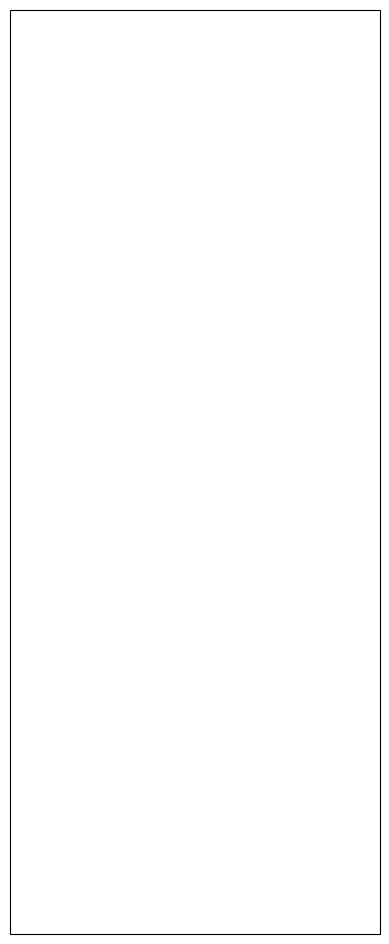

In [ ]:
import matplotlib.pyplot as plt
import geopandas as gpd
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

# Daten laden
basins_lev4_africa = gpd.read_file('./data/HydroBasins/hybas_af_lev01-12_v1c/hybas_af_lev04_v1c.shp')

# Nach MAIN_BAS gruppieren und auflösen
basins_dissolved = basins_lev4_africa.dissolve(by="MAIN_BAS", as_index=False)  
nile = basins_lev4_africa[basins_lev4_africa["MAIN_BAS"]==1040034260]
# Nach MAIN_BAS gruppieren und auflösen
nile_diss = nile.dissolve()
# Figur erstellen
fig, ax = plt.subplots(
    figsize=(16, 12),
    subplot_kw={'projection': ccrs.PlateCarree()}
)

# Zoom auf Nil Region (Nordost-Afrika)
ax.set_extent([20, 40, -10, 40], crs=ccrs.PlateCarree())

# Farbpalette für die verschiedenen Einzugsgebiete
n_basins = len(basins_dissolved)
colors = plt.cm.tab20(np.linspace(0, 1, n_basins))

# Einzugsgebiete plotten mit verschiedenen Farben
nile_diss.plot(
    ax=ax, 
    color=colors, 
    edgecolor="black", 
    linewidth=1.5,
    alpha=0.7
)

# Beschriftungen hinzufügen (größere Schrift beim Zoom)
for idx, row in basins_dissolved.iterrows():
    centroid = row.geometry.centroid
    # Nur Beschriftungen im sichtbaren Bereich (NIL-REGION!)
    if 20 <= centroid.x <= 40 and -10 <= centroid.y <= 40:
        ax.text(
            centroid.x, 
            centroid.y, 
            str(row['MAIN_BAS']), 
            fontsize=10, 
            ha='center',
            fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.8, edgecolor='black')
        )

# Kartografische Features hinzufügen
ax.add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.3)
ax.add_feature(cfeature.OCEAN, facecolor='lightblue', alpha=0.5)
ax.add_feature(cfeature.COASTLINE, linewidth=1)
ax.add_feature(cfeature.BORDERS, linestyle='-', linewidth=1, edgecolor='black')

# RIVERS Feature kann Probleme machen - optional auskommentieren
try:
    ax.add_feature(cfeature.RIVERS, linewidth=1, edgecolor='blue')
except:
    pass  # Falls RIVERS nicht verfügbar ist

# Gitterlinien hinzufügen
gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False

ax.set_title("Nil Region - Einzugsgebiete (MAIN_BAS)", fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()

NameError: name 'basins_dissolved' is not defined

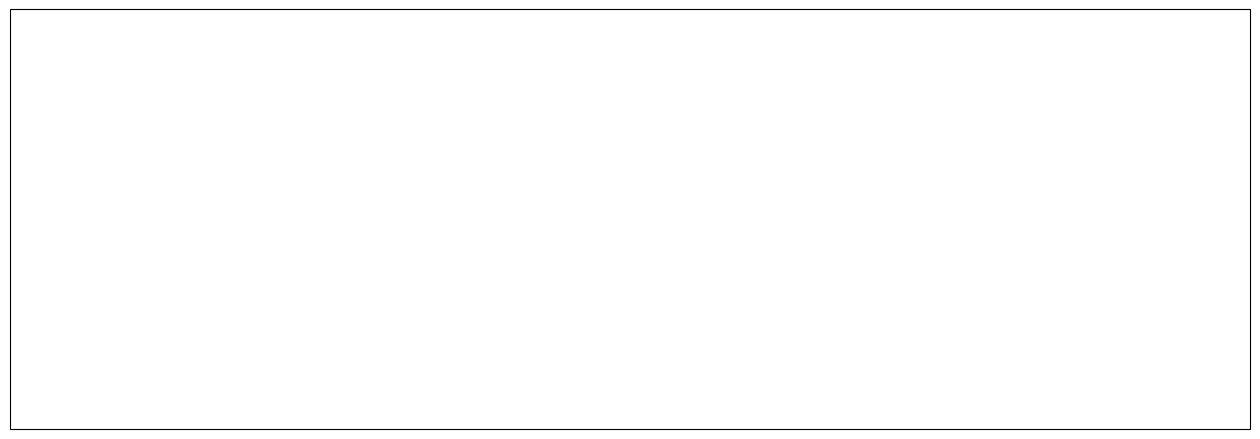

In [5]:
import matplotlib.pyplot as plt
import geopandas as gpd
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

# Daten laden
basins_lev4_na = gpd.read_file('./data/HydroBasins/hybas_na_lev01-12_v1c/hybas_na_lev04_v1c.shp')

# Nach MAIN_BAS gruppieren und auflösen
#basins_diss = basins_lev4_na.dissolve(by="MAIN_BAS", as_index=False)  
missipi = basins_lev4_na[basins_lev4_na["MAIN_BAS"]==7040047060 ]
# Nach MAIN_BAS gruppieren und auflösen
missipi_diss = missipi.dissolve()
# Figur erstellen
fig, ax = plt.subplots(
    figsize=(16, 12),
    subplot_kw={'projection': ccrs.PlateCarree()}
)

# Zoom auf Nil Region (Nordost-Afrika)
ax.set_extent([-130, -65, 29, 51], crs=ccrs.PlateCarree())

# Farbpalette für die verschiedenen Einzugsgebiete
n_basins = len(basins_dissolved)
colors = plt.cm.tab20(np.linspace(0, 1, n_basins))

# Einzugsgebiete plotten mit verschiedenen Farben
missipi_diss.plot(
    ax=ax, 
    color=colors, 
    edgecolor="black", 
    linewidth=1.5,
    alpha=0.7
)

# Beschriftungen hinzufügen (größere Schrift beim Zoom)
for idx, row in basins_dissolved.iterrows():
    centroid = row.geometry.centroid
    # Nur Beschriftungen im sichtbaren Bereich (NIL-REGION!)
    if -130 <= centroid.x <= -60 and 29 <= centroid.y <= 51:
        ax.text(
            centroid.x, 
            centroid.y, 
            str(row['MAIN_BAS']), 
            fontsize=10, 
            ha='center',
            fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.8, edgecolor='black')
        )

# Kartografische Features hinzufügen
ax.add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.3)
ax.add_feature(cfeature.OCEAN, facecolor='lightblue', alpha=0.5)
ax.add_feature(cfeature.COASTLINE, linewidth=1)
ax.add_feature(cfeature.BORDERS, linestyle='-', linewidth=1, edgecolor='black')

# RIVERS Feature kann Probleme machen - optional auskommentieren
try:
    ax.add_feature(cfeature.RIVERS, linewidth=1, edgecolor='blue')
except:
    pass  # Falls RIVERS nicht verfügbar ist

# Gitterlinien hinzufügen
gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False

ax.set_title("Nil Region - Einzugsgebiete (MAIN_BAS)", fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()

In [6]:

import xarray as xr

In [71]:
nile = basins_lev4_africa[basins_lev4_africa["MAIN_BAS"]==1040034260]
# Nach MAIN_BAS gruppieren und auflösen
nile

,HYBAS_ID,NEXT_DOWN,NEXT_SINK,MAIN_BAS,DIST_SINK,DIST_MAIN,SUB_AREA,UP_AREA,PFAF_ID,ENDO,COAST,ORDER,SORT,geometry


In [2]:
basins_lev4_europa = gpd.read_file('./data/HydroBasins/hybas_eu_lev01-12_v1c/hybas_eu_lev04_v1c.shp')

rhine = basins_lev4_europa[basins_lev4_europa["MAIN_BAS"] == 2040023010]#2040022160

rhine_diss = rhine.dissolve()

#Yellow River
basins_lev4_asia = gpd.read_file('./data/HydroBasins/hybas_as_lev01-12_v1c/hybas_as_lev04_v1c.shp')

yellow_river = basins_lev4_asia[basins_lev4["MAIN_BAS"]==4040007850]

yellow_river_diss = yellow_river.dissolve()

#Nile
basins_lev4_africa = gpd.read_file('./data/HydroBasins/hybas_af_lev01-12_v1c/hybas_af_lev04_v1c.shp')

nile = basins_lev4_africa[basins_lev4_africa["MAIN_BAS"]==1040034260]

nile_diss = nile.dissolve()

#Mississippi
basins_lev4_na = gpd.read_file('./data/HydroBasins/hybas_na_lev01-12_v1c/hybas_na_lev04_v1c.shp')

missipi = basins_lev4_na[basins_lev4_na["MAIN_BAS"]==7040047060 ]

missipi_diss = missipi.dissolve()



NameError: name 'basins_lev4' is not defined

In [87]:
main_rivers = {"Rhine": ['./data/HydroBasins/hybas_eu_lev01-12_v1c/hybas_eu_lev04_v1c.shp', 2040023010],
               "Yellow River": ['./data/HydroBasins/hybas_as_lev01-12_v1c/hybas_as_lev04_v1c.shp', 4040007850],
               "Nile": ['./data/HydroBasins/hybas_af_lev01-12_v1c/hybas_af_lev04_v1c.shp', 1040034260],
               "Mississippi": ['./data/HydroBasins/hybas_na_lev01-12_v1c/hybas_na_lev04_v1c.shp', 7040047060]}

for river, (filepath, Basin_ID) in main_rivers.items():
    print(river)
    print(filepath)
    print(Basin_ID)

Rhine
./data/HydroBasins/hybas_eu_lev01-12_v1c/hybas_eu_lev04_v1c.shp
2040023010
Yellow River
./data/HydroBasins/hybas_as_lev01-12_v1c/hybas_as_lev04_v1c.shp
4040007850
Nile
./data/HydroBasins/hybas_af_lev01-12_v1c/hybas_af_lev04_v1c.shp
1040034260
Mississippi
./data/HydroBasins/hybas_na_lev01-12_v1c/hybas_na_lev04_v1c.shp
7040047060


In [77]:
nile_diss

,geometry,HYBAS_ID,NEXT_DOWN,NEXT_SINK,MAIN_BAS,DIST_SINK,DIST_MAIN,SUB_AREA,UP_AREA,PFAF_ID,ENDO,COAST,ORDER,SORT
0,"POLYGON ((29.82083 4.55833, 29.81446 4.5589, 2...",1040034260,0,1040034260,1040034260,0.0,0.0,797088.8,2916808.3,1721,0,0,1,147


In [5]:
import numpy as np
import xarray as xr

In [20]:
ds_150 = xr.open_dataset('./results/snow_dataset_150_tg.nc')
ds_ctrl = xr.open_dataset('./results/snow_dataset_nw_cntrl_03.nc')

In [7]:
#Maske die zurückgibt, wieviel Prozent einer Rasterzelle in Einzugsgebiet liegen (als Bruch)
def create_mask(ds: xr.Dataset, shape: gpd.GeoDataFrame) -> xr.DataArray:
    """
    Create a fractional land mask from a GADM shapefile for the lat/lon grid of a dataset.
    
    Parameters
    ----------
    ds : xr.Dataset
        Dataset containing 'lat' and 'lon' coordinates
    shape : Geodataframe
        Geodataframe with shapes/polygons
    
    Returns
    -------
    land_mask_xr : xr.DataArray
        Fractional land mask (0.0-1.0 representing fraction of cell inside shape)
        with same lat/lon as dataset.
        Longitude is returned in 0-360 range for einfache Verwendung.
    """
    from shapely.geometry import box
    
    # local copy of dataset
    ds_temp = ds.copy()
    
    # change longitude from [0, 360] to [-180, 180] for spatial join
    ds_temp = ds_temp.assign_coords(lon=((ds_temp.lon + 180) % 360) - 180).sortby("lon")
    lat = ds_temp.lat.values
    lon = ds_temp.lon.values
    res_lat = lat[1] - lat[0]
    res_lon = lon[1] - lon[0]
    
    # create grid cell polygons
    polygons = [
        box(x - res_lon / 2, y - res_lat / 2, x + res_lon / 2, y + res_lat / 2)
        for y in lat
        for x in lon
    ]
    cells_gdf = gpd.GeoDataFrame(geometry=polygons, crs="EPSG:4326")
    
    # Merge all shapes into one polygon (falls mehrere Polygone im GeoDataFrame)
    shape_union = shape.unary_union
    
    # Calculate fractional coverage for each cell
    fractional_coverage = np.zeros(len(polygons), dtype=float)
    
    for i, cell in enumerate(cells_gdf.geometry):
        if cell.intersects(shape_union):
            intersection = cell.intersection(shape_union)
            fractional_coverage[i] = intersection.area / cell.area
    
    # Reshape to 2D grid
    land_mask = fractional_coverage.reshape(len(lat), len(lon))
    
    land_mask_xr = xr.DataArray(
        land_mask,
        coords={"lat": lat, "lon": lon},
        dims=("lat", "lon"),
        name="land_mask",
    )
    
    # bring longitude back to [0, 360] range
    land_mask_xr = land_mask_xr.assign_coords(
        lon=((land_mask_xr.lon + 360) % 360)
    ).sortby("lon")
    
    return land_mask_xr

In [11]:
def create_land_mask(ds: xr.Dataset, shape: gpd.GeoDataFrame ) -> xr.DataArray:
    """
    Create a boolean land mask from a GADM shapefile for the lat/lon grid of a dataset.

    Parameters
    ----------
    ds : xr.Dataset
        Dataset containing 'lat' and 'lon' coordinates
    shape : Geodataframe
        Geodataframe with shapes/polygons

    Returns
    -------
    land_mask_xr : xr.DataArray
        Boolean land mask (True = land) with same lat/lon as dataset.
        Longitude is returned in 0-360 range for einfache Verwendung.
    """
    from shapely.geometry import box
    # local copy of dataset
    ds_temp = ds.copy()

    # change longitude from [0, 360] to [-180, 180] for spatial join
    ds_temp = ds_temp.assign_coords(lon=((ds_temp.lon + 180) % 360) - 180).sortby("lon")

    lat = ds_temp.lat.values
    lon = ds_temp.lon.values
    res_lat = lat[1] - lat[0]
    res_lon = lon[1] - lon[0]

    # create grid cell polygons
    polygons = [
        box(x - res_lon / 2, y - res_lat / 2, x + res_lon / 2, y + res_lat / 2)
        for y in lat
        for x in lon
    ]

    cells_gdf = gpd.GeoDataFrame(geometry=polygons, crs="EPSG:4326")

    # Spatial join: only cell polygons that intersect with land area polygons
    cells_land = gpd.sjoin(cells_gdf, shape, how="inner", predicate="intersects")

    # create boolean land mask
    land_mask_flat = np.zeros(len(polygons), dtype=bool)
    land_mask_flat[cells_land.index.values] = True
    land_mask = land_mask_flat.reshape(len(lat), len(lon))

    land_mask_xr = xr.DataArray(
        land_mask,
        coords={"lat": lat, "lon": lon},
        dims=("lat", "lon"),
        name="land_mask",
    )

    # bring longitude back to [0, 360] range
    land_mask_xr = land_mask_xr.assign_coords(
        lon=((land_mask_xr.lon + 360) % 360)
    ).sortby("lon")

    return land_mask_xr

In [21]:
rhine_mask = create_mask(ds_150, rhine_diss)

/var/folders/1c/sw4rp72s7bl5g97s7r1grdm00000gn/T/ipykernel_59616/2566240448.py:41: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  shape_union = shape.unary_union


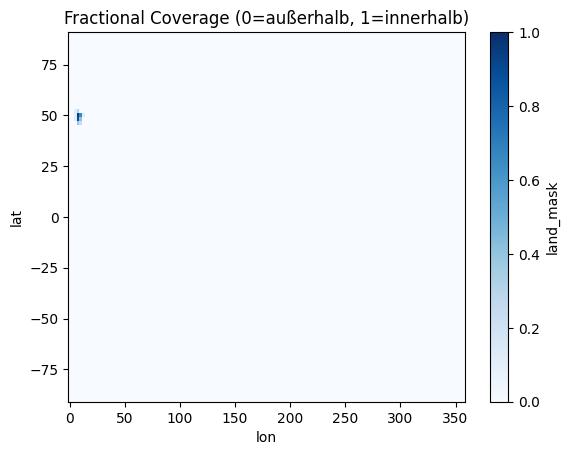

In [9]:
import matplotlib.pyplot as plt

rhine_mask.plot(cmap='Blues', vmin=0, vmax=1)
plt.title('Fractional Coverage (0=außerhalb, 1=innerhalb)')
plt.show()


In [120]:
ds_150

<xarray.Dataset>
Dimensions:          (time: 360, lat: 96, lon: 144)
Coordinates:
  * lat              (lat) float64 -90.0 -88.11 -86.21 ... 86.21 88.11 90.0
  * lon              (lon) float64 0.0 2.5 5.0 7.5 ... 350.0 352.5 355.0 357.5
  * time             (time) object 0005-02-01 00:00:00 ... 0035-01-01 00:00:00
Data variables:
    PRECC            (time, lat, lon) float32 ...
    PRECL            (time, lat, lon) float32 ...
    TS               (time, lat, lon) float32 ...
    TSMN             (time, lat, lon) float32 ...
    TSMX             (time, lat, lon) float32 ...
    days_in_month    (time, lat, lon) float64 ...
    precip_mm_month  (time, lat, lon) float64 ...
    t_mean_celsius   (time, lat, lon) float32 ...
    snow_storage     (time, lat, lon) float32 4.383 4.377 4.382 ... nan nan nan
    snow_melt        (time, lat, lon) float32 0.0 0.0 0.0 0.0 ... nan nan nan
Attributes:
    Conventions:      CF-1.0
    source:           CAM
    case:             nw_ur_150_07
    title:            UNSET
    logname:          bardeenc
    host:             shas0139
    Version:          $Name$
    revision_Id:      $Id$
    initial_file:     /projects/bardeenc/inputdata/f2000.e10r02.2deg.waccm.00...
    topography_file:  /gpfs/summit/datasets/CESM/inputdata/atm/cam/topo/consi...
    history:          Mon Oct 21 08:34:38 2024: ncks -v TS,TSMN,TSMX,PRECC,PR...
    NCO:              netCDF Operators version 5.1.4 (Homepage = http://nco.s...

In [23]:
ds_rhine_150 = ds_150.where(rhine_mask >0)
ds_rhine_control = ds_ctrl.where(rhine_mask >0)



In [24]:
R = 6371000
lat_rad = np.deg2rad(ds_rhine.lat.values)
lon_rad = np.deg2rad(ds_rhine.lon.values)
dlat = np.abs(lat_rad[1] - lat_rad[0])
dlon = np.abs(lon_rad[1] - lon_rad[0])
    
    # 2D Zellflächenarray (lat, lon)
cell_area = (R**2) * dlat * dlon * np.cos(lat_rad)[:, None]
    
    # ---- 2. Snow_Melt in Meter ----
snow_melt_m = ds_rhine_150.snow_melt / 1000  # mm -> m
    
    # ---- 3. Volumen pro Zelle ----
volume_cells_150 = snow_melt_m * cell_area * rhine_mask

In [25]:
R = 6371000
lat_rad = np.deg2rad(ds_rhine.lat.values)
lon_rad = np.deg2rad(ds_rhine.lon.values)
dlat = np.abs(lat_rad[1] - lat_rad[0])
dlon = np.abs(lon_rad[1] - lon_rad[0])
    
    # 2D Zellflächenarray (lat, lon)
cell_area = (R**2) * dlat * dlon * np.cos(lat_rad)[:, None]
    
    # ---- 2. Snow_Melt in Meter ----
snow_melt_control = ds_rhine_control.snow_melt / 1000  # mm -> m
    
    # ---- 3. Volumen pro Zelle ----
volume_cells_control = snow_melt_control * cell_area * rhine_mask

In [27]:
total_volume_monthly = volume_cells.sum(dim=["lat","lon"], skipna=True)
seconds_in_month = 30*24*3600  # grob, alternativ kalendarisch je Monat
total_discharge_m3s_control = total_volume_monthly / seconds_in_month



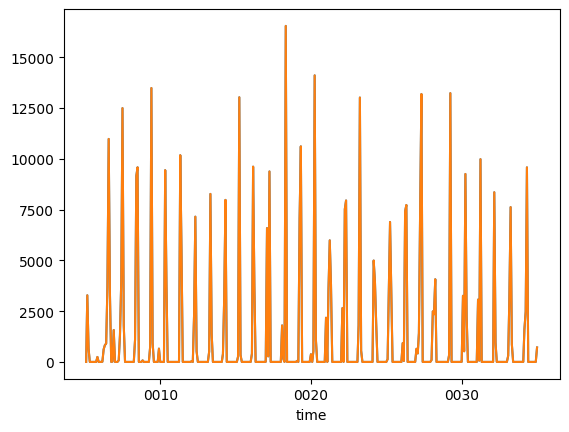

In [28]:
total_discharge_m3s_150.plot()
total_discharge_m3s_control.plot()


In [ ]:
4.28687662e+10 / (30 * 24 * 60 * 60)



16538.87584876543

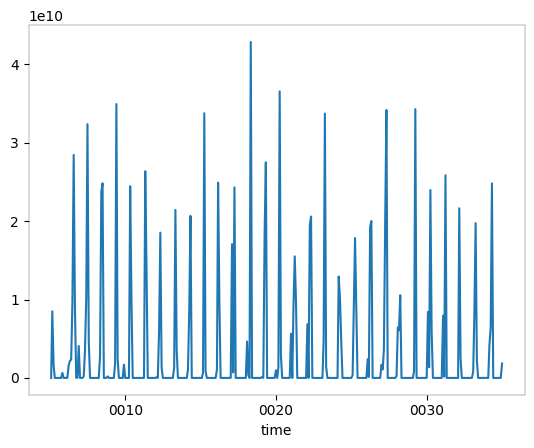

In [135]:
volume_cells.sum(dim=("lat","lon")).plot()

In [113]:
ds_150

<xarray.Dataset>
Dimensions:          (time: 360, lat: 96, lon: 144)
Coordinates:
  * lat              (lat) float64 -90.0 -88.11 -86.21 ... 86.21 88.11 90.0
  * lon              (lon) float64 0.0 2.5 5.0 7.5 ... 350.0 352.5 355.0 357.5
  * time             (time) object 0005-02-01 00:00:00 ... 0035-01-01 00:00:00
Data variables:
    PRECC            (time, lat, lon) float32 ...
    PRECL            (time, lat, lon) float32 ...
    TS               (time, lat, lon) float32 ...
    TSMN             (time, lat, lon) float32 ...
    TSMX             (time, lat, lon) float32 ...
    days_in_month    (time, lat, lon) float64 ...
    precip_mm_month  (time, lat, lon) float64 ...
    t_mean_celsius   (time, lat, lon) float32 ...
    snow_storage     (time, lat, lon) float32 4.383 4.377 4.382 ... nan nan nan
    snow_melt        (time, lat, lon) float32 0.0 0.0 0.0 0.0 ... nan nan nan
Attributes:
    Conventions:      CF-1.0
    source:           CAM
    case:             nw_ur_150_07
    title:            UNSET
    logname:          bardeenc
    host:             shas0139
    Version:          $Name$
    revision_Id:      $Id$
    initial_file:     /projects/bardeenc/inputdata/f2000.e10r02.2deg.waccm.00...
    topography_file:  /gpfs/summit/datasets/CESM/inputdata/atm/cam/topo/consi...
    history:          Mon Oct 21 08:34:38 2024: ncks -v TS,TSMN,TSMX,PRECC,PR...
    NCO:              netCDF Operators version 5.1.4 (Homepage = http://nco.s...

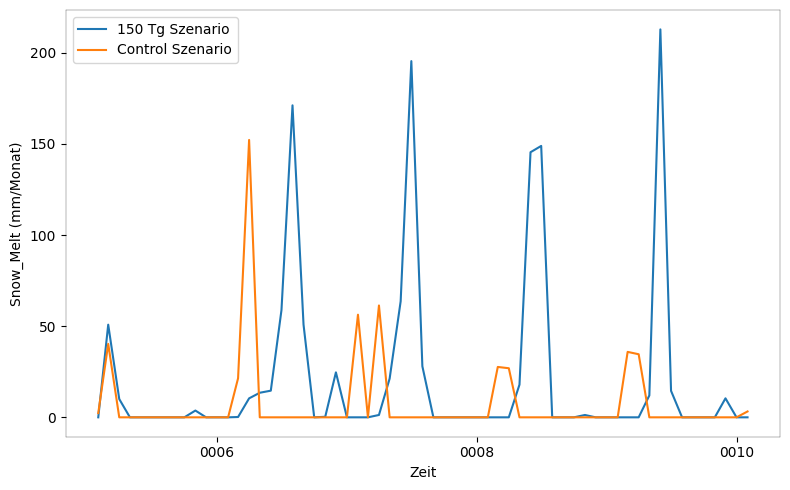

In [118]:

ds_150_mean_normal = ds_150_rhine.snow_melt.mean(dim=["lat","lon"])
ds_ctrl_mean = ds_ctrl_rhine.snow_melt.mean(dim=["lat","lon"])

ds_150_mean=ds_150_mean.sel(time=slice(cftime.DatetimeNoLeap(5, 2, 1, 0, 0, 0, 0, has_year_zero=True),cftime.DatetimeNoLeap(10, 2, 1, 0, 0, 0, 0, has_year_zero=True)))
ds_ctrl_mean=ds_ctrl_mean.sel(time=slice(cftime.DatetimeNoLeap(5, 2, 1, 0, 0, 0, 0, has_year_zero=True),cftime.DatetimeNoLeap(10, 2, 1, 0, 0, 0, 0, has_year_zero=True)))



# Neue Figur und Achse erzeugen
fig, ax = plt.subplots(figsize=(8, 5))

# Beide Zeitreihen in dieselbe Achse plotten
ds_150_mean.plot(ax=ax, label="150 Tg Szenario")
ds_ctrl_mean.plot(ax=ax, label="Control Szenario")

# Achsenbeschriftung (optional, aber empfehlenswert)
ax.set_xlabel("Zeit")
ax.set_ylabel("Snow_Melt (mm/Monat)")

# Legende hinzufügen
ax.legend()

# Layout verbessern
plt.tight_layout()
plt.show()




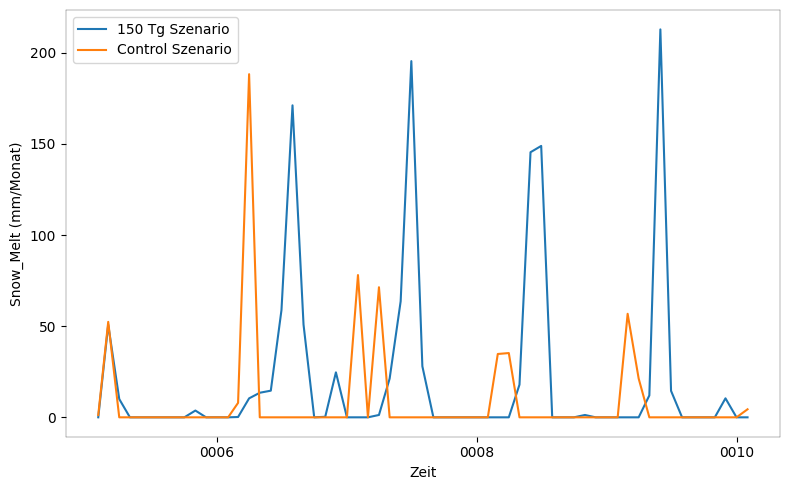

In [116]:

ds_150_mean = (ds_150_rhine.snow_melt * rhine_mask).sum(
            dim=["lat", "lon"]
        ) / rhine_mask.sum(dim=["lat", "lon"])
ds_ctrl_mean = (ds_ctrl_rhine.snow_melt * rhine_mask).sum(
            dim=["lat", "lon"]
        ) / rhine_mask.sum(dim=["lat", "lon"])

ds_150_mean=ds_150_mean.sel(time=slice(cftime.DatetimeNoLeap(5, 2, 1, 0, 0, 0, 0, has_year_zero=True),cftime.DatetimeNoLeap(10, 2, 1, 0, 0, 0, 0, has_year_zero=True)))
ds_ctrl_mean=ds_ctrl_mean.sel(time=slice(cftime.DatetimeNoLeap(5, 2, 1, 0, 0, 0, 0, has_year_zero=True),cftime.DatetimeNoLeap(10, 2, 1, 0, 0, 0, 0, has_year_zero=True)))



# Neue Figur und Achse erzeugen
fig, ax = plt.subplots(figsize=(8, 5))

# Beide Zeitreihen in dieselbe Achse plotten
ds_150_mean.plot(ax=ax, label="150 Tg Szenario")
ds_ctrl_mean.plot(ax=ax, label="Control Szenario")

# Achsenbeschriftung (optional, aber empfehlenswert)
ax.set_xlabel("Zeit")
ax.set_ylabel("Snow_Melt (mm/Monat)")

# Legende hinzufügen
ax.legend()

# Layout verbessern
plt.tight_layout()
plt.show()




In [119]:
print(ds_150_mean)
print(ds_150_mean_normal)

<xarray.DataArray (time: 61)>
array([0.00000000e+00, 5.08451206e+01, 1.00290637e+01, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 3.72078450e+00, 0.00000000e+00, 1.13109276e-02,
       0.00000000e+00, 1.74598053e-01, 1.04101137e+01, 1.34824469e+01,
       1.46301825e+01, 5.88894188e+01, 1.71220577e+02, 5.08646459e+01,
       0.00000000e+00, 2.97705395e-01, 2.46782079e+01, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 1.28806888e+00, 2.12451462e+01,
       6.36850355e+01, 1.95486089e+02, 2.80185955e+01, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 1.79277873e+01,
       1.45479255e+02, 1.48944264e+02, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 1.28563133e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 1.20128164e+01,
       2.12891637e+02, 1.45334700e+01, 0.000000

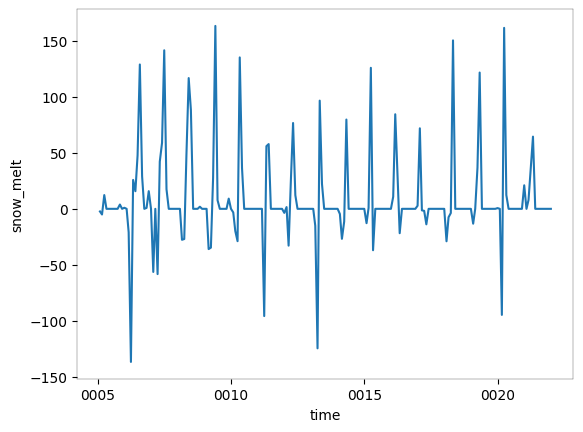

In [ ]:
ds_diff = ds_150.snow_melt.mean(dim=["lat","lon"]) - ds_ctrl.snow_melt.mean(dim=["lat","lon"])
ds_diff.plot()

In [ ]:
ds_diff = ds_150.snow_melt - ds_ctrl.snow_melt
weights = np.cos(np.deg2rad(ds_diff.lat))
weights.name = "weights"

ts = ds_diff.weighted(weights).mean(dim=["lat", "lon"])



In [108]:
river_mask

NameError: name 'river_mask' is not defined

In [16]:
ts.plot()

NameError: name 'ts' is not defined

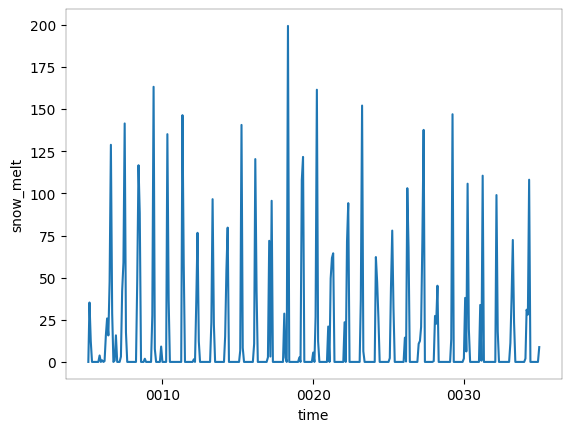

In [31]:
ds_150_rhine.snow_melt.mean(dim=["lat","lon"]).plot()

In [18]:
ts_year = ts.resample(time="1Y").mean()
ts_year.plot()


NameError: name 'ts' is not defined

In [19]:
ts_quarter = ts.resample(time="QS-DEC").mean()

ts_quarter.plot()


NameError: name 'ts' is not defined

In [105]:
data = ds_150_rhine.snow_storage.max(dim="time")

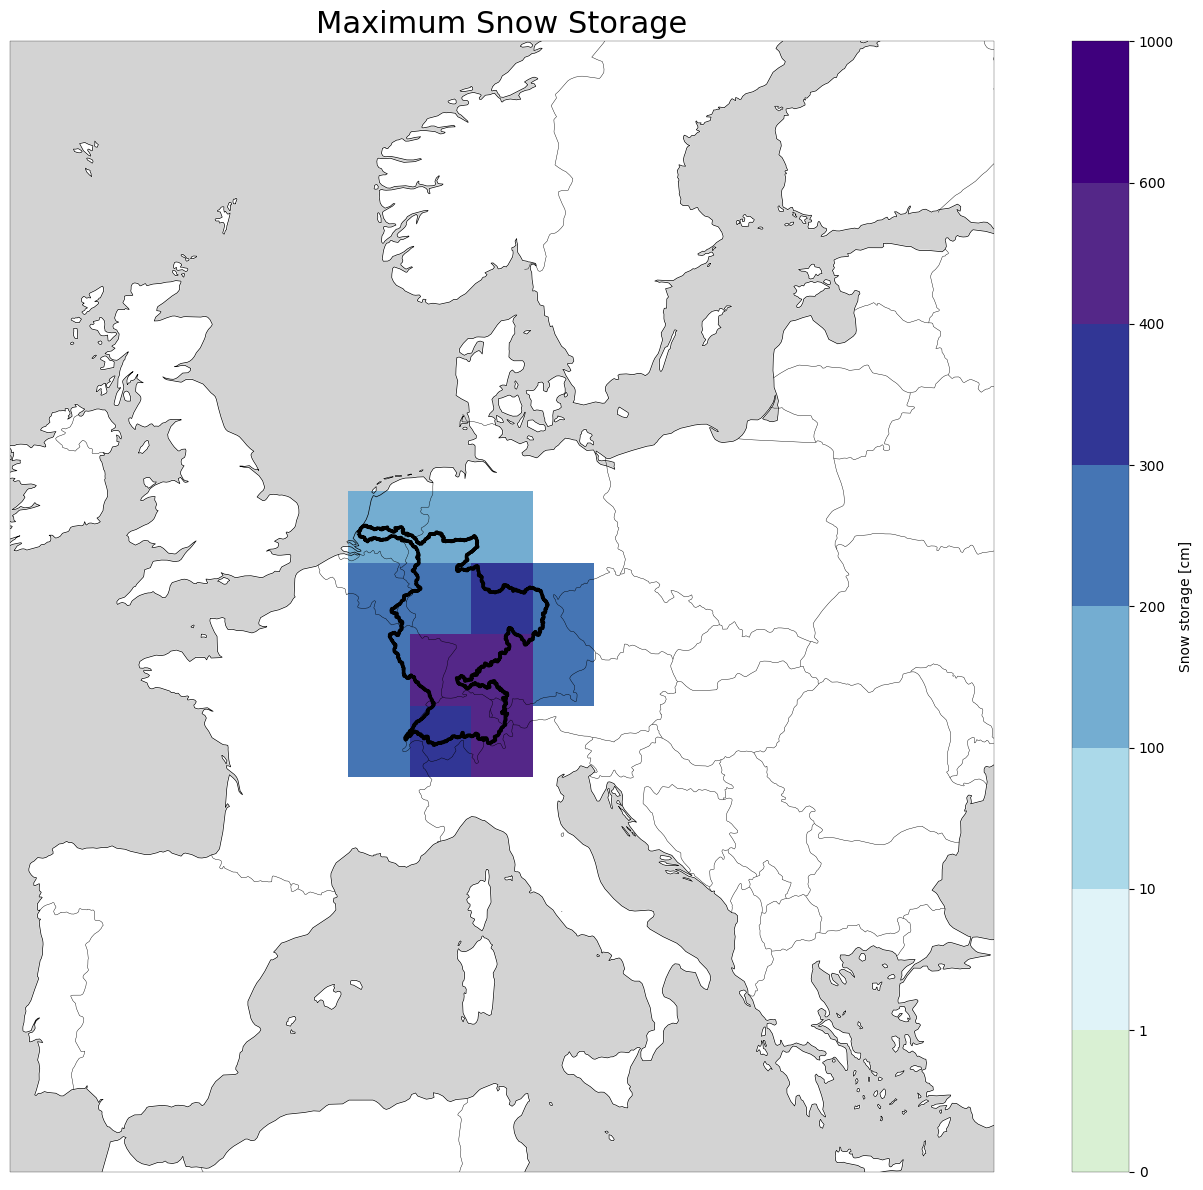

In [106]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.colors as mcolors
import numpy as np

# ---- Sicherstellen, dass Rhine in WGS84 ist ----
if rhine.crs != "EPSG:4326":
    rhine = rhine.to_crs("EPSG:4326")

plt.rcParams.update({
    "axes.edgecolor": "black",
    "axes.linewidth": 0.2,
})

bin_edges = np.array([0, 1, 10, 100, 200, 300, 400, 600, 1000])
n_classes = len(bin_edges) - 1

colors = [
    "#d9f0d3",  # schneefrei
    "#e0f3f8",
    "#abd9e9",
    "#74add1",
    "#4575b4",
    "#313695",
    "#542788",
    "#3f007d",
]

cmap = mcolors.ListedColormap(colors)
norm = mcolors.BoundaryNorm(bin_edges, ncolors=n_classes)

fig, ax = plt.subplots(
    figsize=(16, 12),
    subplot_kw={'projection': ccrs.PlateCarree()}
)

# Europa-Ausdehnung
ax.set_extent([-10, 30, 35, 65], crs=ccrs.PlateCarree())

# Hintergrund zuerst!
ax.add_feature(cfeature.OCEAN, color='lightgrey', zorder=0)
ax.add_feature(cfeature.LAND, color='white', zorder=0)

# Snow-Daten
im = data.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap=cmap,
    norm=norm,
    add_colorbar=True,
    cbar_kwargs={
        "label": "Snow storage [cm]",
        "ticks": bin_edges
    },
    zorder=5
)

# Rhein-Gebiet deutlich sichtbar
rhine.boundary.plot(
    ax=ax,
    edgecolor="black",
    linewidth=2.5,
    transform=ccrs.PlateCarree(),
    zorder=20
)

# Optional: halbtransparent füllen
# rhine.plot(
#     ax=ax,
#     facecolor="none",
#     edgecolor="black",
#     linewidth=2.5,
#     transform=ccrs.PlateCarree(),
#     zorder=20
# )

ax.coastlines(linewidth=0.5, zorder=10)
ax.add_feature(cfeature.BORDERS, linewidth=0.3, zorder=10)

ax.set_title("Maximum Snow Storage", fontsize=22)

plt.tight_layout()
plt.show()


In [47]:

ds_150_mean = ds_150_rhine.snow_melt.mean(dim=["lat","lon"])
ds_150_mean

<xarray.DataArray 'snow_melt' (time: 360)>
array([  0.        ,  35.24007   ,  12.270857  ,   0.        ,
         0.        ,   0.        ,   0.        ,   0.        ,
         0.        ,   3.8367689 ,   0.        ,   0.9679391 ,
         0.        ,   0.48121664,  15.610166  ,  25.794926  ,
        15.725318  ,  47.69647   , 128.81075   ,  29.034445  ,
         0.        ,   0.82051766,  15.769019  ,   0.        ,
         0.        ,   0.        ,   3.1403286 ,  42.09063   ,
        58.94934   , 141.47658   ,  17.490559  ,   0.        ,
         0.        ,   0.        ,   0.        ,   0.        ,
         0.        ,   0.        ,   0.        ,  48.20008   ,
       116.688896  ,  88.31148   ,   0.        ,   0.        ,
         0.        ,   1.8806803 ,   0.        ,   0.        ,
         0.        ,   0.        ,   0.        ,  27.70384   ,
       163.22475   ,   7.7091546 ,   0.        ,   0.        ,
         0.        ,   0.        ,   9.120607  ,   0.        ,
         0.        ,   0.        ,   0.        , 135.1198    ,
        36.593845  ,   0.        ,   0.        ,   0.        ,
         0.        ,   0.        ,   0.        ,   0.        ,
         0.        ,   0.        ,   0.        , 146.39702   ,
        57.781178  ,   0.        ,   0.        ,   0.        ,
...
         0.        ,   0.        ,   0.        ,   0.        ,
         0.        ,  13.586648  , 146.9371    ,   0.        ,
         0.        ,   0.        ,   0.        ,   0.        ,
         0.        ,   0.        ,   0.        ,   2.0758862 ,
        37.994595  ,   6.2145996 , 105.73479   ,  19.61462   ,
         0.        ,   0.        ,   0.        ,   0.        ,
         0.        ,   0.        ,   0.        ,   0.        ,
        33.81198   ,   0.7470703 , 110.48924   ,   0.        ,
         0.        ,   0.        ,   0.        ,   0.        ,
         0.        ,   0.        ,   0.        ,   0.        ,
         0.        ,  98.98798   ,  17.94959   ,   0.        ,
         0.        ,   0.        ,   0.        ,   0.        ,
         0.        ,   0.        ,   0.        ,   0.        ,
        11.250883  ,  37.12168   ,  72.34081   ,  23.529968  ,
         0.        ,   0.        ,   0.        ,   0.        ,
         0.        ,   0.        ,   0.        ,   0.        ,
         1.9961548 ,  30.97894   ,  28.11075   , 108.10051   ,
         0.        ,   0.        ,   0.        ,   0.        ,
         0.        ,   0.        ,   0.        ,   8.789825  ],
      dtype=float32)
Coordinates:
  * time     (time) object 0005-02-01 00:00:00 ... 0035-01-01 00:00:00

In [48]:
import xarray as xr
import cftime

# Einen Monat zurück verschieben
ds_150_mean = ds_150_mean.assign_coords(
    time=[
        cftime.DatetimeNoLeap(t.year if t.month > 1 else t.year - 1,
                              t.month - 1 if t.month > 1 else 12,
                              1)
        for t in ds_150_mean.time.values
    ]
)


In [49]:
ds_150_mean

<xarray.DataArray 'snow_melt' (time: 360)>
array([  0.        ,  35.24007   ,  12.270857  ,   0.        ,
         0.        ,   0.        ,   0.        ,   0.        ,
         0.        ,   3.8367689 ,   0.        ,   0.9679391 ,
         0.        ,   0.48121664,  15.610166  ,  25.794926  ,
        15.725318  ,  47.69647   , 128.81075   ,  29.034445  ,
         0.        ,   0.82051766,  15.769019  ,   0.        ,
         0.        ,   0.        ,   3.1403286 ,  42.09063   ,
        58.94934   , 141.47658   ,  17.490559  ,   0.        ,
         0.        ,   0.        ,   0.        ,   0.        ,
         0.        ,   0.        ,   0.        ,  48.20008   ,
       116.688896  ,  88.31148   ,   0.        ,   0.        ,
         0.        ,   1.8806803 ,   0.        ,   0.        ,
         0.        ,   0.        ,   0.        ,  27.70384   ,
       163.22475   ,   7.7091546 ,   0.        ,   0.        ,
         0.        ,   0.        ,   9.120607  ,   0.        ,
         0.        ,   0.        ,   0.        , 135.1198    ,
        36.593845  ,   0.        ,   0.        ,   0.        ,
         0.        ,   0.        ,   0.        ,   0.        ,
         0.        ,   0.        ,   0.        , 146.39702   ,
        57.781178  ,   0.        ,   0.        ,   0.        ,
...
         0.        ,   0.        ,   0.        ,   0.        ,
         0.        ,  13.586648  , 146.9371    ,   0.        ,
         0.        ,   0.        ,   0.        ,   0.        ,
         0.        ,   0.        ,   0.        ,   2.0758862 ,
        37.994595  ,   6.2145996 , 105.73479   ,  19.61462   ,
         0.        ,   0.        ,   0.        ,   0.        ,
         0.        ,   0.        ,   0.        ,   0.        ,
        33.81198   ,   0.7470703 , 110.48924   ,   0.        ,
         0.        ,   0.        ,   0.        ,   0.        ,
         0.        ,   0.        ,   0.        ,   0.        ,
         0.        ,  98.98798   ,  17.94959   ,   0.        ,
         0.        ,   0.        ,   0.        ,   0.        ,
         0.        ,   0.        ,   0.        ,   0.        ,
        11.250883  ,  37.12168   ,  72.34081   ,  23.529968  ,
         0.        ,   0.        ,   0.        ,   0.        ,
         0.        ,   0.        ,   0.        ,   0.        ,
         1.9961548 ,  30.97894   ,  28.11075   , 108.10051   ,
         0.        ,   0.        ,   0.        ,   0.        ,
         0.        ,   0.        ,   0.        ,   8.789825  ],
      dtype=float32)
Coordinates:
  * time     (time) object 0005-01-01 00:00:00 ... 0034-12-01 00:00:00

In [32]:
ds_150_mean.sum("time")

<xarray.DataArray 'snow_melt' ()>
array(5348.5728, dtype=float32)

In [37]:
annual_sum_150 = ds_150_mean.groupby("time.year").sum("time")
annual_sum_150


<xarray.DataArray 'snow_melt' (year: 30)>
array([ 52.31563 , 279.7428  , 263.14743 , 255.08112 , 207.75835 ,
       171.71364 , 204.17819 , 126.677155, 142.28653 , 149.67361 ,
       155.68039 , 175.61821 , 170.64243 , 230.73619 , 237.72327 ,
       221.56099 , 175.6406  , 189.1755  , 195.39514 , 135.73172 ,
       156.43456 , 196.25171 , 243.89072 ,  95.15297 , 162.59964 ,
       169.55861 , 145.0483  , 116.93758 , 144.24335 , 177.97618 ],
      dtype=float32)
Coordinates:
  * year     (year) int64 5 6 7 8 9 10 11 12 13 ... 26 27 28 29 30 31 32 33 34

In [56]:
rhine_seasonal = ds_150_mean.groupby("time.season").sum("time")
rhine_seasonal



<xarray.DataArray 'snow_melt' (season: 4)>
array([ 967.46936 ,  460.52942 , 3889.1462  ,   31.427593], dtype=float32)
Coordinates:
  * season   (season) object 'DJF' 'JJA' 'MAM' 'SON'

In [26]:
import cftime
def mean_annual_sum(da):
    da_mean = da.mean(dim=["lat","lon"])
    da_mean = da_mean.assign_coords(
    time=[
        cftime.DatetimeNoLeap(t.year if t.month > 1 else t.year - 1,
                              t.month - 1 if t.month > 1 else 12,
                              1)
        for t in da_mean.time.values
    ])
    return da_mean.groupby("time.year").sum("time")  


    

TypeError: Plotting requires coordinates to be numeric, boolean, or dates of type numpy.datetime64, datetime.datetime, cftime.datetime or pandas.Interval. Received data of type object instead.

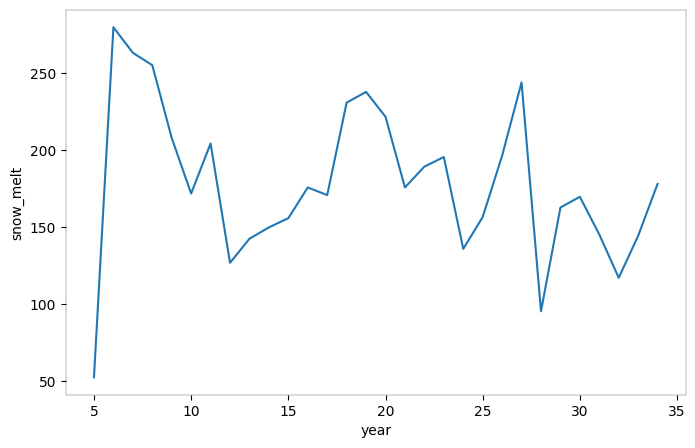

In [ ]:
rhine_150 = mean_annual_sum(ds_150_rhine.snow_melt)
rhine_ctrl = mean_annual_sum(ds_ctrl_rhine.snow_melt)

# Neue Figur und Achse erzeugen
fig, ax = plt.subplots(figsize=(8, 5))

# Beide Zeitreihen in dieselbe Achse plotten
rhine_150.plot(ax=ax, label="150 Tg Szenario")
rhine_ctrl.plot(ax=ax, label="Control Szenario")

# Achsenbeschriftung (optional, aber empfehlenswert)
ax.set_xlabel("Zeit")
ax.set_ylabel("Snow_Melt (mm/Jahr)")

# Legende hinzufügen
ax.legend()

# Layout verbessern
plt.tight_layout()
plt.show()

In [60]:
yellow_river_mask = create_land_mask(ds_150, yellow_river_diss)
yellow_river_mask

<xarray.DataArray 'land_mask' (lat: 96, lon: 144)>
array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False]])
Coordinates:
  * lat      (lat) float64 -90.0 -88.11 -86.21 -84.32 ... 84.32 86.21 88.11 90.0
  * lon      (lon) float64 0.0 2.5 5.0 7.5 10.0 ... 350.0 352.5 355.0 357.5

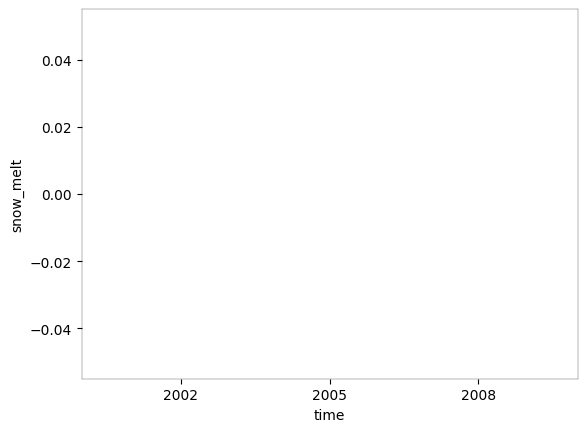

In [65]:
ds_150_yellow_river = ds_150.where(yellow_river_mask)
ds_ctrl_yellow_river = ds_ctrl.where(yellow_river_mask)

ds_150_yellow_river.snow_melt.mean(dim=["lat","lon"]).plot()
ds_ctrl_yellow_river.snow_melt.mean(dim=["lat","lon"]).plot()



In [66]:
ds_150_yellow_river.snow_melt.mean(dim=["lat","lon"])

<xarray.DataArray 'snow_melt' (time: 360)>
array([nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan], dtype=float32)
Coordinates:
  * time     (time) object 0005-02-01 00:00:00 ... 0035-01-01 00:00:00

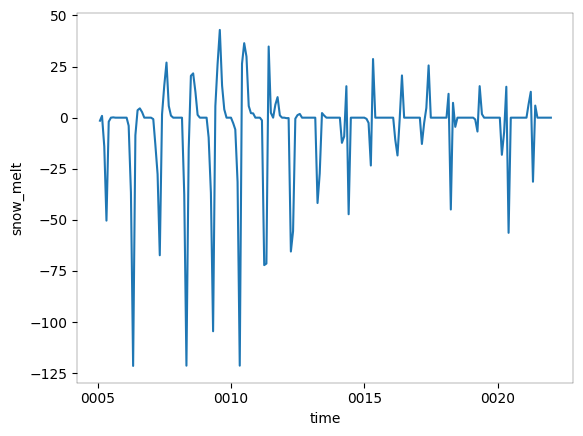

In [54]:
ds_yellow_river_diff = ds_150_yellow_river.snow_melt.mean(dim=["lat","lon"]) - ds_ctrl_yellow_river.snow_melt.mean(dim=["lat","lon"])
ds_yellow_river_diff.plot()

In [56]:
ds_diff_yellow_river = ds_150_yellow_river.snow_melt - ds_ctrl_yellow_river.snow_melt
weights = np.cos(np.deg2rad(ds_diff_yellow_river.lat))
weights.name = "weights"

ts = ds_diff_yellow_river.weighted(weights).mean(dim=["lat", "lon"])

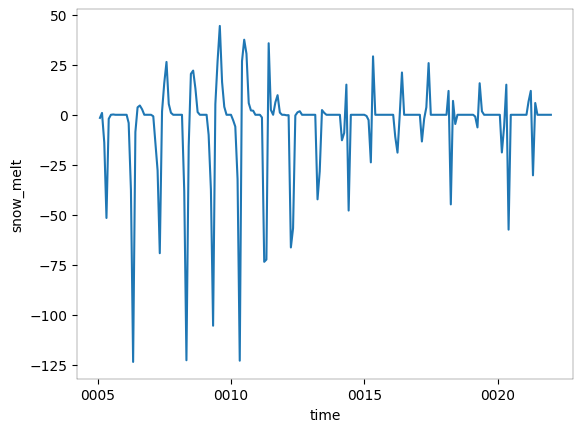

In [57]:
ts.plot()

In [68]:
data_yellow_river = ds_150_yellow_river.snow_melt.max(dim="time")

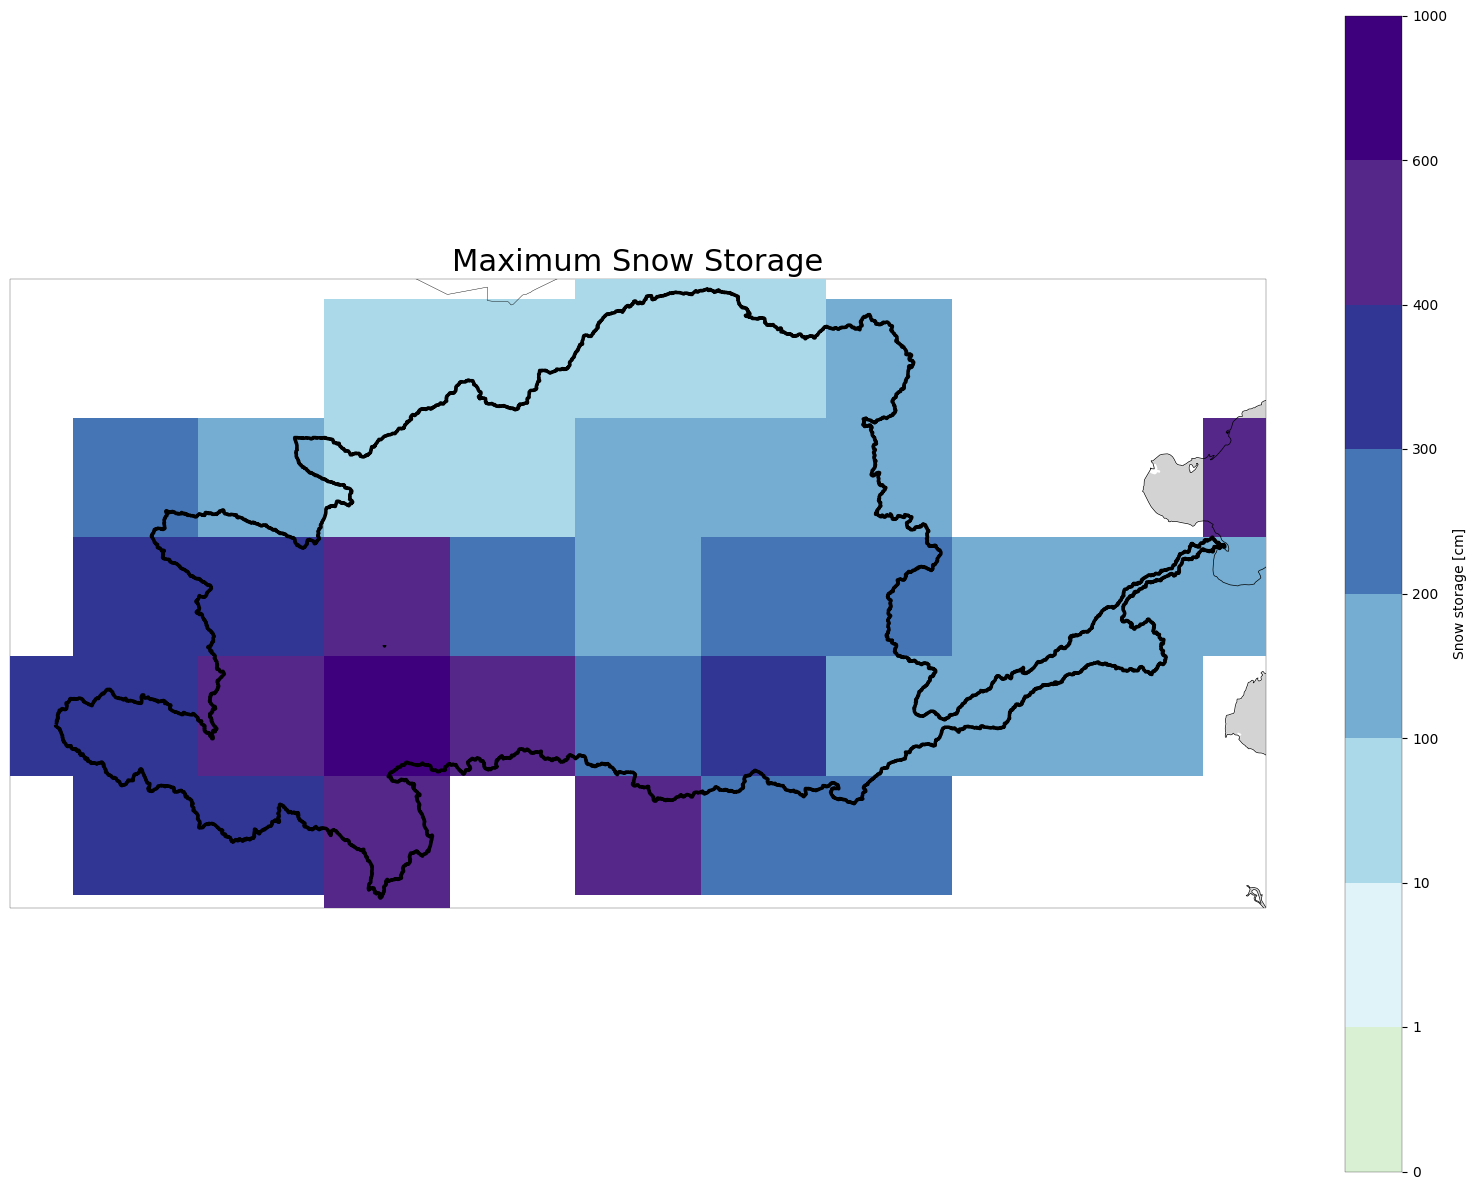

In [ ]:


import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.colors as mcolors
import numpy as np

# ---- Sicherstellen, dass Rhine in WGS84 ist ----
if yellow_river_diss.crs != "EPSG:4326":
    yellow_river = yellow_river_diss.to_crs("EPSG:4326")

plt.rcParams.update({
    "axes.edgecolor": "black",
    "axes.linewidth": 0.2,
})

bin_edges = np.array([0, 1, 10, 100, 200, 300, 400, 600, 1000])
n_classes = len(bin_edges) - 1

colors = [
    "#d9f0d3",  # schneefrei
    "#e0f3f8",
    "#abd9e9",
    "#74add1",
    "#4575b4",
    "#313695",
    "#542788",
    "#3f007d",
]

cmap = mcolors.ListedColormap(colors)
norm = mcolors.BoundaryNorm(bin_edges, ncolors=n_classes)

fig, ax = plt.subplots(
    figsize=(16, 12),
    subplot_kw={'projection': ccrs.PlateCarree()}
)

# Europa-Ausdehnung
ax.set_extent([95, 120, 32, 42], crs=ccrs.PlateCarree())

# Hintergrund zuerst!
ax.add_feature(cfeature.OCEAN, color='lightgrey', zorder=0)
ax.add_feature(cfeature.LAND, color='white', zorder=0)

# Snow-Daten
im = data_yellow_river.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap=cmap,
    norm=norm,
    add_colorbar=True,
    cbar_kwargs={
        "label": "Snow storage [cm]",
        "ticks": bin_edges
    },
    zorder=5
)

# Rhein-Gebiet deutlich sichtbar
yellow_river_diss.boundary.plot(
    ax=ax,
    edgecolor="black",
    linewidth=2.5,
    transform=ccrs.PlateCarree(),
    zorder=20
)

# Optional: halbtransparent füllen
# rhine.plot(
#     ax=ax,
#     facecolor="none",
#     edgecolor="black",
#     linewidth=2.5,
#     transform=ccrs.PlateCarree(),
#     zorder=20
# )

ax.coastlines(linewidth=0.5, zorder=10)
ax.add_feature(cfeature.BORDERS, linewidth=0.3, zorder=10)

ax.set_title("Maximum Snow Melt", fontsize=22)

plt.tight_layout()
plt.show()


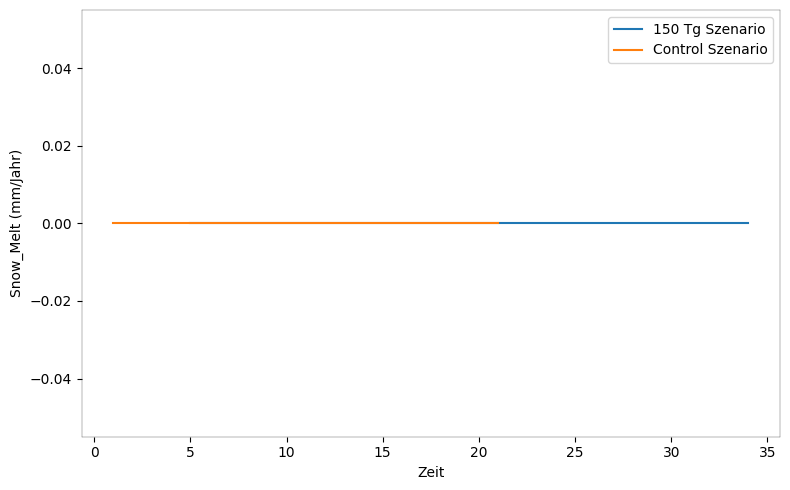

In [62]:
yr_150 = mean_annual_sum(ds_150_yellow_river.snow_melt)
yr_ctrl = mean_annual_sum(ds_ctrl_yellow_river.snow_melt)

# Neue Figur und Achse erzeugen
fig, ax = plt.subplots(figsize=(8, 5))

# Beide Zeitreihen in dieselbe Achse plotten
yr_150.plot(ax=ax, label="150 Tg Szenario")
yr_ctrl.plot(ax=ax, label="Control Szenario")

# Achsenbeschriftung (optional, aber empfehlenswert)
ax.set_xlabel("Zeit")
ax.set_ylabel("Snow_Melt (mm/Jahr)")

# Legende hinzufügen
ax.legend()

# Layout verbessern
plt.tight_layout()
plt.show()

In [110]:
nile = basins_lev4_africa[basins_lev4_africa["MAIN_BAS"]==1040034260]
nile_diss = nile.dissolve()
nile_diss

,geometry,HYBAS_ID,NEXT_DOWN,NEXT_SINK,MAIN_BAS,DIST_SINK,DIST_MAIN,SUB_AREA,UP_AREA,PFAF_ID,ENDO,COAST,ORDER,SORT
0,"POLYGON ((29.82083 4.55833, 29.81446 4.5589, 2...",1040034260,0,1040034260,1040034260,0.0,0.0,797088.8,2916808.3,1721,0,0,1,147


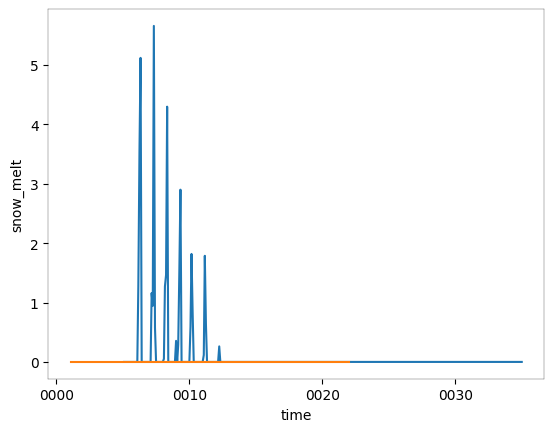

In [111]:
nile_mask = create_land_mask(ds_150, nile_diss)

ds_150_nile = ds_150.where(nile_mask)
ds_ctrl_nile = ds_ctrl.where(nile_mask)

ds_150_nile.snow_melt.mean(dim=["lat","lon"]).plot()
ds_ctrl_nile.snow_melt.mean(dim=["lat","lon"]).plot()



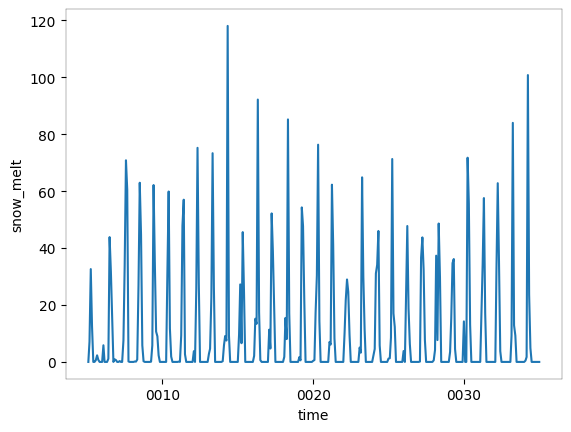

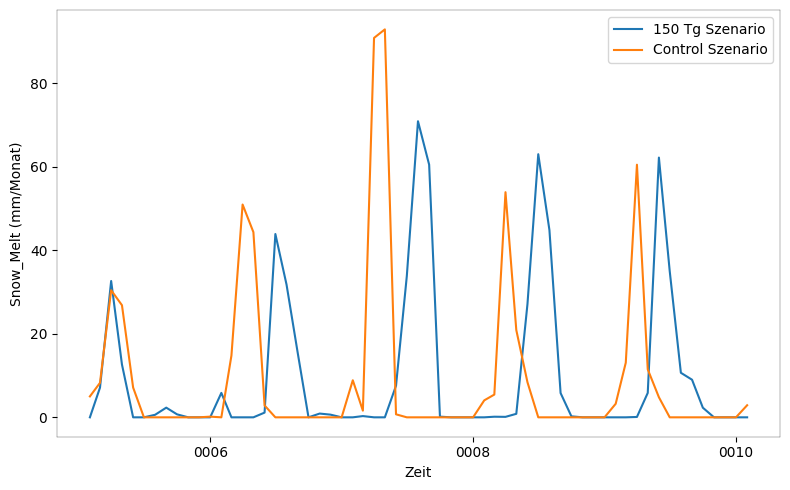

In [130]:
import cftime
missipi_mask = create_land_mask(ds_150, missipi_diss)

ds_150_missipi = ds_150.where(missipi_mask)
ds_ctrl_missipi = ds_ctrl.where(missipi_mask)

ds_150_mean = ds_150_missipi.snow_melt.mean(dim=["lat","lon"])
ds_ctrl_mean = ds_ctrl_missipi.snow_melt.mean(dim=["lat","lon"])

ds_150_mean.plot()

ds_150_mean=ds_150_mean.sel(time=slice(cftime.DatetimeNoLeap(5, 2, 1, 0, 0, 0, 0, has_year_zero=True),cftime.DatetimeNoLeap(10, 2, 1, 0, 0, 0, 0, has_year_zero=True)))
ds_ctrl_mean=ds_ctrl_mean.sel(time=slice(cftime.DatetimeNoLeap(5, 2, 1, 0, 0, 0, 0, has_year_zero=True),cftime.DatetimeNoLeap(10, 2, 1, 0, 0, 0, 0, has_year_zero=True)))



# Neue Figur und Achse erzeugen
fig, ax = plt.subplots(figsize=(8, 5))

# Beide Zeitreihen in dieselbe Achse plotten
ds_150_mean.plot(ax=ax, label="150 Tg Szenario")
ds_ctrl_mean.plot(ax=ax, label="Control Szenario")

# Achsenbeschriftung (optional, aber empfehlenswert)
ax.set_xlabel("Zeit")
ax.set_ylabel("Snow_Melt (mm/Monat)")

# Legende hinzufügen
ax.legend()

# Layout verbessern
plt.tight_layout()
plt.show()




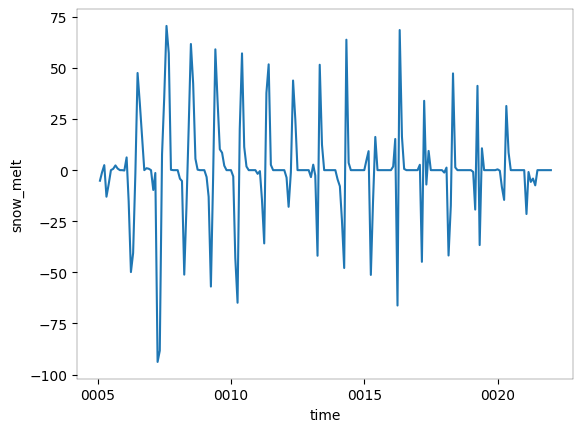

In [119]:
ds_diff_missipi = ds_150_missipi.snow_melt - ds_ctrl_missipi.snow_melt
weights = np.cos(np.deg2rad(ds_diff_missipi.lat))
weights.name = "weights"

ts = ds_diff_missipi.weighted(weights).mean(dim=["lat", "lon"])
ts.plot()

In [121]:
ds_150

<xarray.Dataset>
Dimensions:          (time: 360, lat: 96, lon: 144)
Coordinates:
  * lat              (lat) float64 -90.0 -88.11 -86.21 ... 86.21 88.11 90.0
  * lon              (lon) float64 0.0 2.5 5.0 7.5 ... 350.0 352.5 355.0 357.5
  * time             (time) object 0005-02-01 00:00:00 ... 0035-01-01 00:00:00
Data variables:
    PRECC            (time, lat, lon) float32 ...
    PRECL            (time, lat, lon) float32 ...
    TS               (time, lat, lon) float32 ...
    TSMN             (time, lat, lon) float32 ...
    TSMX             (time, lat, lon) float32 ...
    days_in_month    (time, lat, lon) float64 ...
    precip_mm_month  (time, lat, lon) float64 ...
    t_mean_celsius   (time, lat, lon) float32 ...
    snow_storage     (time, lat, lon) float32 ...
    snow_melt        (time, lat, lon) float32 ...
Attributes:
    Conventions:      CF-1.0
    source:           CAM
    case:             nw_ur_150_07
    title:            UNSET
    logname:          bardeenc
    host:             shas0139
    Version:          $Name$
    revision_Id:      $Id$
    initial_file:     /projects/bardeenc/inputdata/f2000.e10r02.2deg.waccm.00...
    topography_file:  /gpfs/summit/datasets/CESM/inputdata/atm/cam/topo/consi...
    history:          Mon Oct 21 08:34:38 2024: ncks -v TS,TSMN,TSMX,PRECC,PR...
    NCO:              netCDF Operators version 5.1.4 (Homepage = http://nco.s...